In [4]:
import numpy as np
from datascience import *

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [5]:
table = Table().with_columns("Ethnicity", ['Asian', 'Black', 'Latino', 'White', 'Other'], "Eligible", [0.15, 0.18, 0.12, 0.54, 0.01], "Panel", [0.26, 0.08, 0.08, 0.54, 0.04])

In [6]:
diff = table.column("Panel") - table.column('Eligible')
table = table.with_column("Diff", diff)

In [7]:
table

Ethnicity,Eligible,Panel,Diff
Asian,0.15,0.26,0.11
Black,0.18,0.08,-0.1
Latino,0.12,0.08,-0.04
White,0.54,0.54,0
Other,0.01,0.04,0.03


In [8]:
model = make_array(0.15, 0.8, 0.12, 0.54, 0.01)

In [9]:
sum(table.column("Diff"))

np.float64(2.7755575615628914e-17)

## The Total Variation Distance (TVD)

In [10]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2)) / 2

In [11]:
obsvd_tvd = tvd(table.column("Panel"), table.column("Eligible"))
obsvd_tvd

np.float64(0.14)

In [12]:
# simulated_tvd = tvd(sample_proportions(1453, model), table.column("Eligible"))

# Model vs alternate viewpoint

In [13]:
def simulated_tvd():
    num = tvd(sample_proportions(1453, model), model)
    return num


model = model / np.sum(model)
tvds = make_array()

num_simulations = 

for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

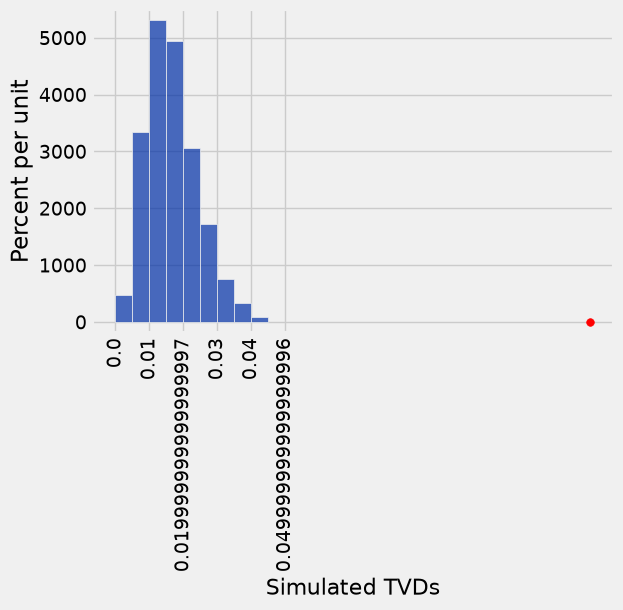

In [31]:
title = 'Simulated TVDs'
bins = np.arange(0, 0.05, 0.005)

average_tbl = Table().with_column(title, tvds)
average_tbl.hist(bins = bins)
plt.ylim(-2, 55)
plt.scatter(obsvd_tvd, 0, color='red', s=30)

In [32]:
p_value = np.count_nonzero(tvd <= section_3_average)/10000
p_vallue

NameError: name 'section_3_average' is not defined

# Assume that our p-value cutoff is 0.05. Demercate:
- the area os the simulated distrubtion that is lower than the section 3 average with a vertical line
- the area covered by the lowest 5 percent (the area to the left of the cutoff)

In [33]:
simulations = 10000

In [34]:
fiver_percent_index = round(simulations * 0.05)
fiver_percent_index

500

In [35]:
sorted_averages = average_tbl.sort(0).column(0)
sorted_averages

array([0.00128725, 0.00140195, 0.00149117, ..., 0.05646045, 0.05703398,
       0.06067481], shape=(10000,))

In [ ]:
five_percent_point = sorted_averages.item(five_percent_index)

In [36]:
tvds.hist(bins=20)
plt.plot([fiver_percent_point, fiver_percent_point], [0, 0.35], color='gold', lw=2)
plt.title("5% of the simulated statistics are to the left of the line!")
plt.scatter(section_3_average, -0.01, color='red', s=60)

NameError: name 'averages_tbl' is not defined

In [ ]:
# 